***CONFIGURACIÓN INICIAL E IMPORTACIÓN DE LIBRERÍAS***

In [37]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos de regresión
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Métricas de evaluación
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Ignorar warnings
import warnings
warnings.filterwarnings('ignore')

***IMPORTACIÓN Y EXPLORACIÓN DATASET***

In [38]:

# ==============================
# CARGA DEL DATASET
# ==============================

df = pd.read_csv("WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv")

# ==============================
# OBSERVACIÓN DATASET
# ==============================

print("Forma del dataset:", df.shape)
print("\nPrimeras 5 filas del dataset:")
display(df.head())

# Total de Filas y Columnas
print(f"Dataset de entrenamiento tiene: {df.shape[0]} filas y {df.shape[1]} columnas")

# Tipos de Datos de cada Columna
datos_info = pd.DataFrame({
    'Columna':df.columns,
    'Tipo':df.dtypes,
    'Valores Únicos':df.nunique()

})

print(datos_info)

# ==============================
# CALIDAD DE DATOS
# ==============================

# Valores nulos
print("\nValores nulos por columna:")
display(df.isnull().sum())

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
display(df.describe())

Forma del dataset: (9134, 24)

Primeras 5 filas del dataset:


,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


Dataset de entrenamiento tiene: 9134 filas y 24 columnas
                                                     Columna     Tipo  \
Customer                                            Customer   object   
State                                                  State   object   
Customer Lifetime Value              Customer Lifetime Value  float64   
Response                                            Response   object   
Coverage                                            Coverage   object   
Education                                          Education   object   
Effective To Date                          Effective To Date   object   
EmploymentStatus                            EmploymentStatus   object   
Gender                                                Gender   object   
Income                                                Income    int64   
Location Code                                  Location Code   object   
Marital Status                                Marital Status   obje

,0
Customer,0
State,0
Customer Lifetime Value,0
Response,0
Coverage,0
Education,0
Effective To Date,0
EmploymentStatus,0
Gender,0
Income,0



Estadísticas descriptivas:


,Customer Lifetime Value,Income,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Total Claim Amount
count,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000
mean,8004.940475,37657.380009,93.219291,15.097000,48.064594,0.384388,2.966170,434.088794
std,6870.967608,30379.904734,34.407967,10.073257,27.905991,0.910384,2.390182,290.500092
min,1898.007675,0.000000,61.000000,0.000000,0.000000,0.000000,1.000000,0.099007
25%,3994.251794,0.000000,68.000000,6.000000,24.000000,0.000000,1.000000,272.258244
50%,5780.182197,33889.500000,83.000000,14.000000,48.000000,0.000000,2.000000,383.945434
75%,8962.167041,62320.000000,109.000000,23.000000,71.000000,0.000000,4.000000,547.514839
max,83325.381190,99981.000000,298.000000,35.000000,99.000000,5.000000,9.000000,2893.239678


***INSIGHTS***


A partir del análisis exploratorio inicial del dataset, se observa que el mismo cuenta con 9.134 registros y 24 variables, combinando tanto variables numéricas como categóricas, lo que lo hace adecuado para un análisis de tipo predictivo.

En términos de calidad de datos, no se identificaron valores nulos en ninguna de las variables, lo que simplifica la etapa de preprocesamiento y permite trabajar directamente con el dataset sin necesidad de imputaciones.

La variable objetivo, Customer Lifetime Value, presenta una alta dispersión, con una media de aproximadamente 8.004 y un valor máximo significativamente elevado, lo que sugiere la presencia de valores extremos y una posible distribución sesgada.

Asimismo, se observa que variables como Income presentan valores mínimos de cero, lo cual podría estar asociado a clientes desempleados o sin ingresos declarados, siendo un aspecto relevante a considerar en el análisis.

Por otro lado, la presencia de múltiples variables categóricas con diferentes niveles (como estado, tipo de póliza o canal de venta) aporta información valiosa que deberá ser transformada adecuadamente para su uso en modelos de machine learning.

En conjunto, el dataset presenta una estructura completa y consistente, adecuada para abordar un problema de regresión orientado a la predicción del valor del cliente, permitiendo avanzar hacia etapas posteriores de análisis exploratorio más profundo y modelado.


***EDA***

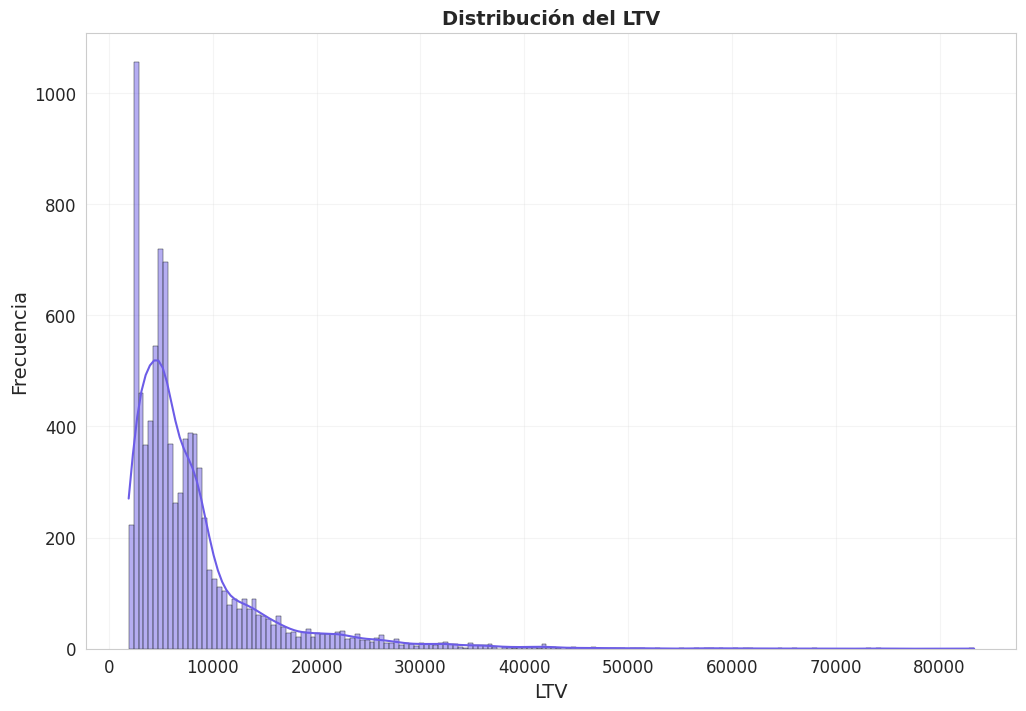

In [39]:
# ==============================
# Distribución del TARGET
# ==============================

plt.figure()

sns.histplot(
    df['Customer Lifetime Value'],
    kde=True,
    color="#6C5CE7",
    edgecolor="#2D3436"
)

plt.title("Distribución del LTV", fontsize=14, fontweight='bold')
plt.xlabel("LTV")
plt.ylabel("Frecuencia")

plt.grid(alpha=0.2)

plt.show()

La distribución del Customer Lifetime Value (LTV) presenta un marcado sesgo hacia la izquierda, evidenciando que la mayoría de los clientes generan un valor relativamente bajo, mientras que un pequeño grupo concentra valores significativamente altos.

Este comportamiento indica la presencia de clientes altamente valiosos, lo que resulta relevante desde el punto de vista de negocio, ya que permite identificar segmentos prioritarios para estrategias de retención y fidelización.

Asimismo, la dispersión observada sugiere la existencia de valores extremos (outliers), lo cual será tenido en cuenta en las etapas posteriores de modelado.

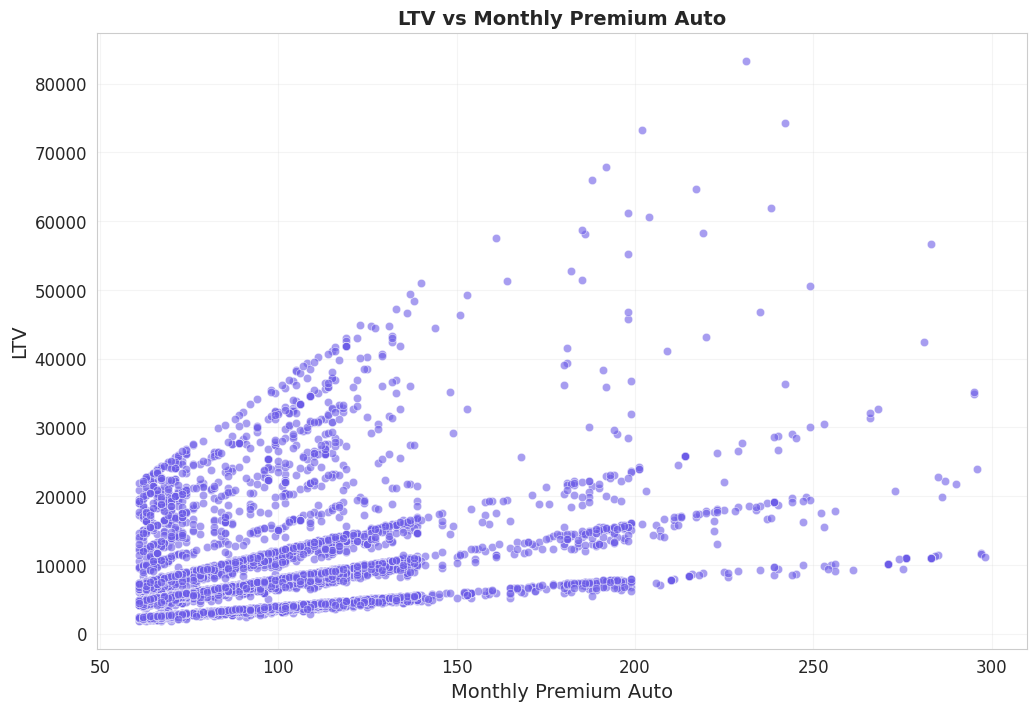

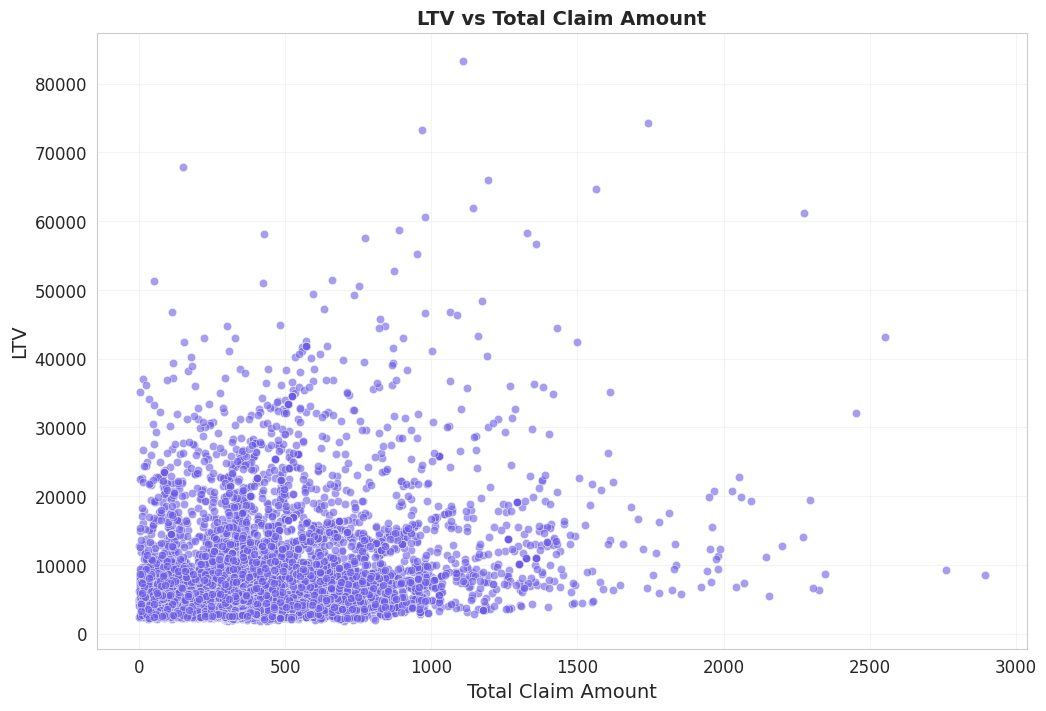

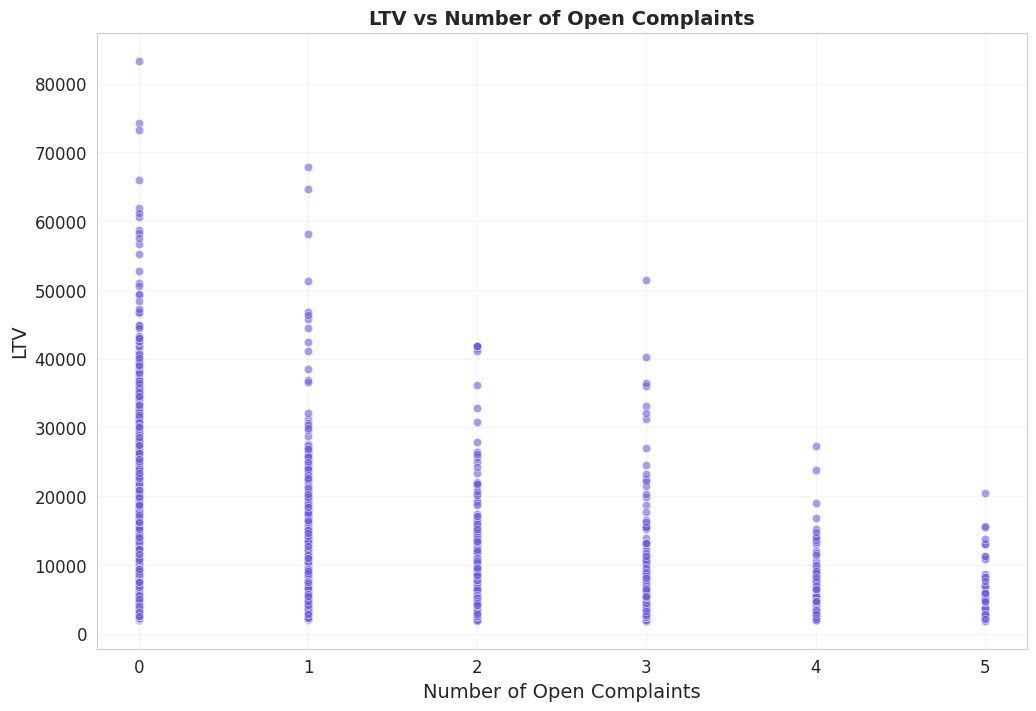

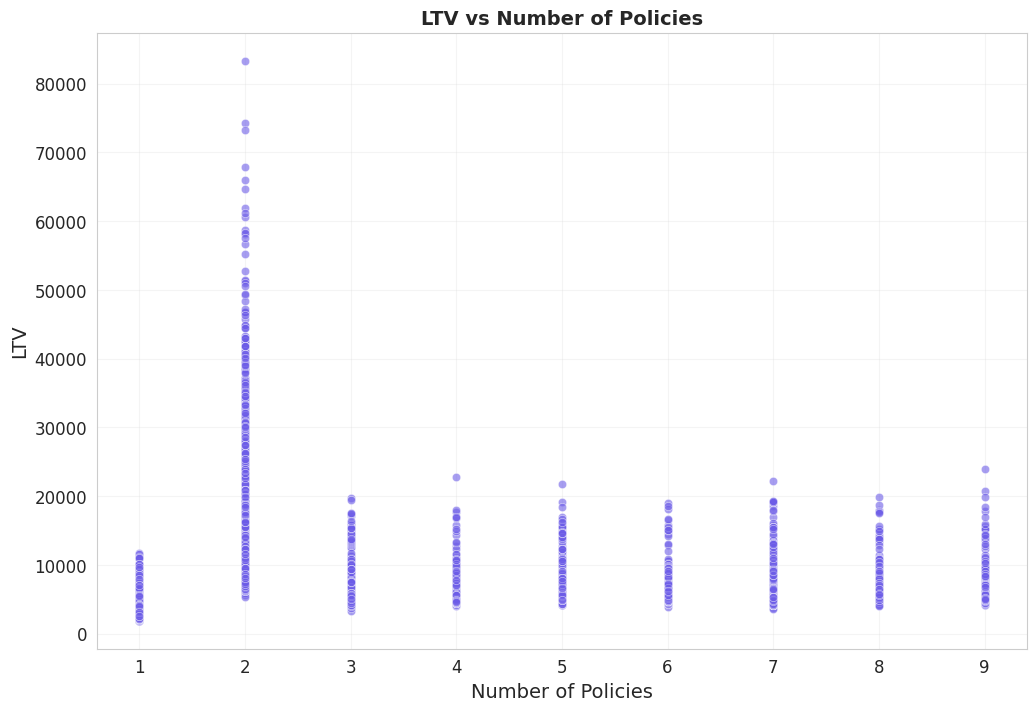

In [40]:
# ==============================
# LTV vs VARIABLES NUMÉRICAS (SELECCIONADAS)
# ==============================

num_cols_selected = [
    'Monthly Premium Auto',
    'Total Claim Amount',
    'Number of Open Complaints',
    'Number of Policies'
]

for col in num_cols_selected:
    plt.figure()

    sns.scatterplot(
        x=df[col],
        y=df['Customer Lifetime Value'],
        color="#6C5CE7",
        alpha=0.6
    )

    plt.title(f"LTV vs {col}", fontsize=14, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel("LTV")

    plt.grid(alpha=0.2)

    plt.show()

#LTV vs Monthly Premium Auto

Se observa una relación positiva entre el LTV y la variable Monthly Premium Auto, indicando que los clientes que pagan primas más elevadas tienden a generar un mayor valor para la empresa. Esto resulta coherente desde el punto de vista de negocio, ya que mayores pagos mensuales implican una mayor contribución económica a lo largo del tiempo.

#LTV vs Total Claim Amount

La variable Total Claim Amount presenta una relación positiva con el LTV, aunque con una alta dispersión. Esto sugiere que clientes con mayor nivel de actividad (medido a través de reclamos) también pueden generar mayor valor, posiblemente debido a una mayor interacción con los servicios de la compañía.

#LTV vs Number of Open Complaints

Se observa una tendencia a que los clientes con mayor cantidad de reclamos abiertos presenten valores de LTV más bajos, lo que podría indicar una relación negativa entre la satisfacción del cliente y su valor a largo plazo.

#LTV vs Number of Policies

Se identifican algunos clientes con múltiples pólizas que alcanzan valores elevados de LTV, lo que sugiere que la diversificación de productos contratados podría estar asociada a un mayor valor del cliente, aunque no se observa una relación lineal clara

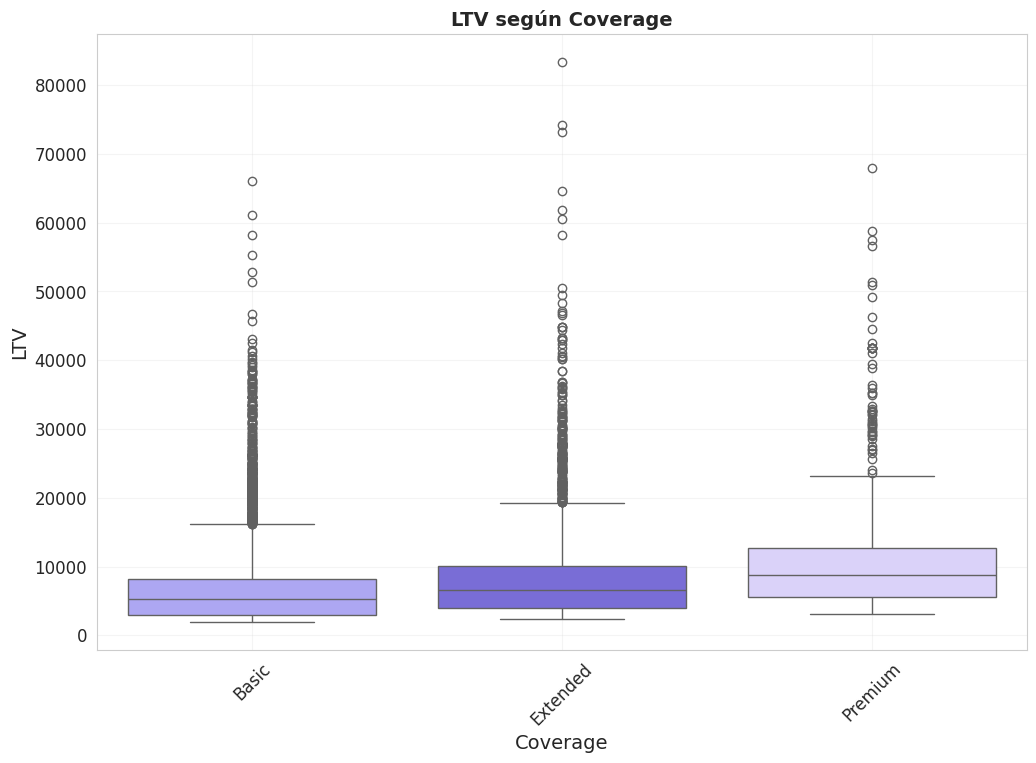

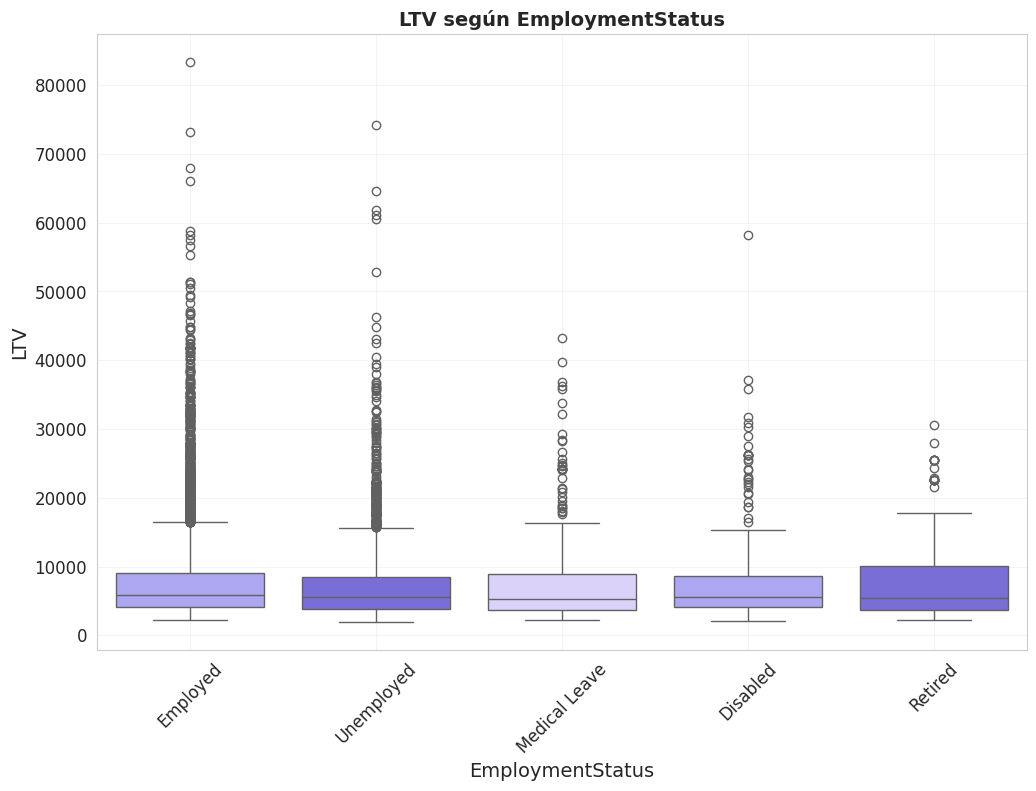

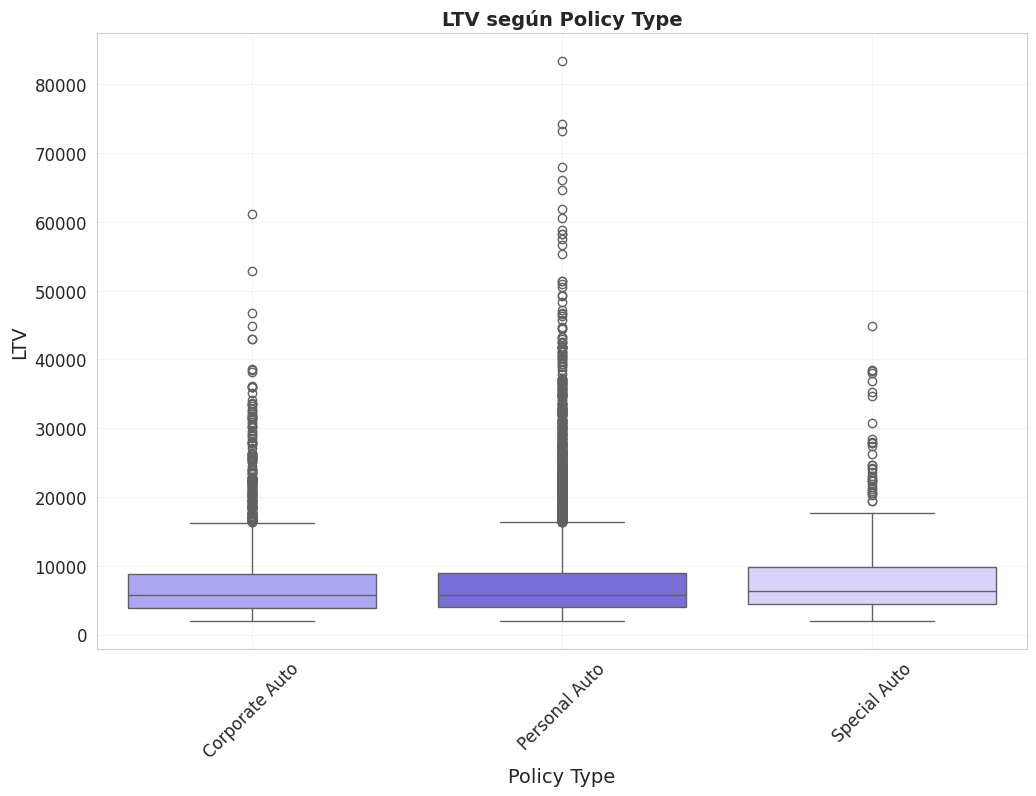

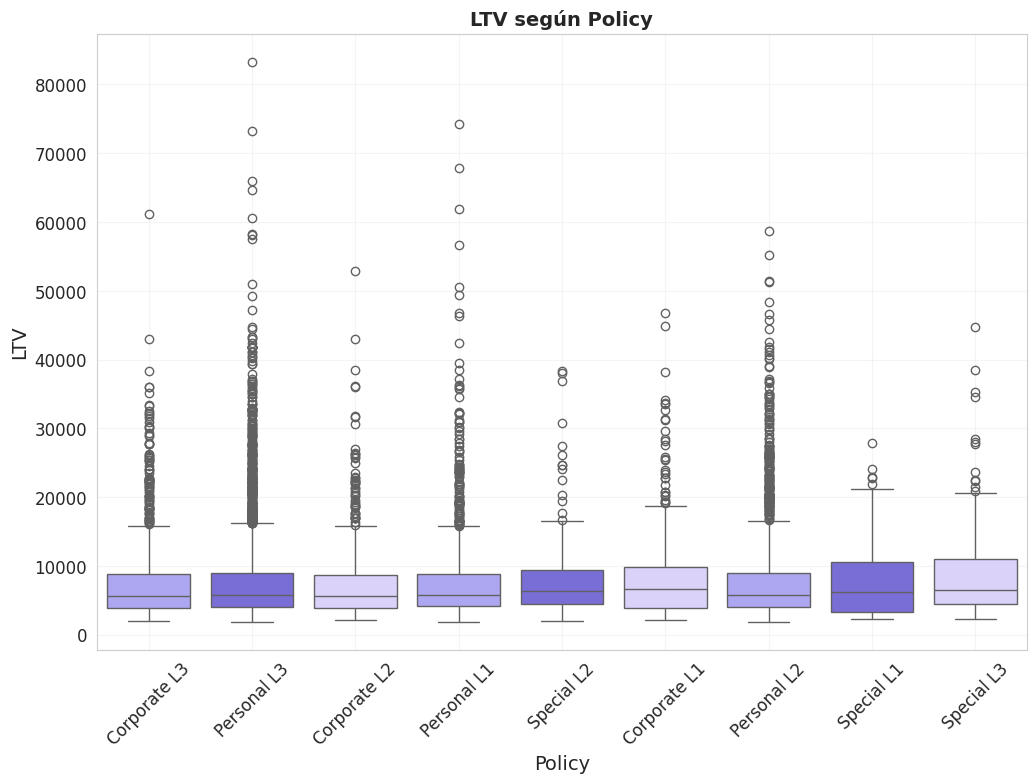

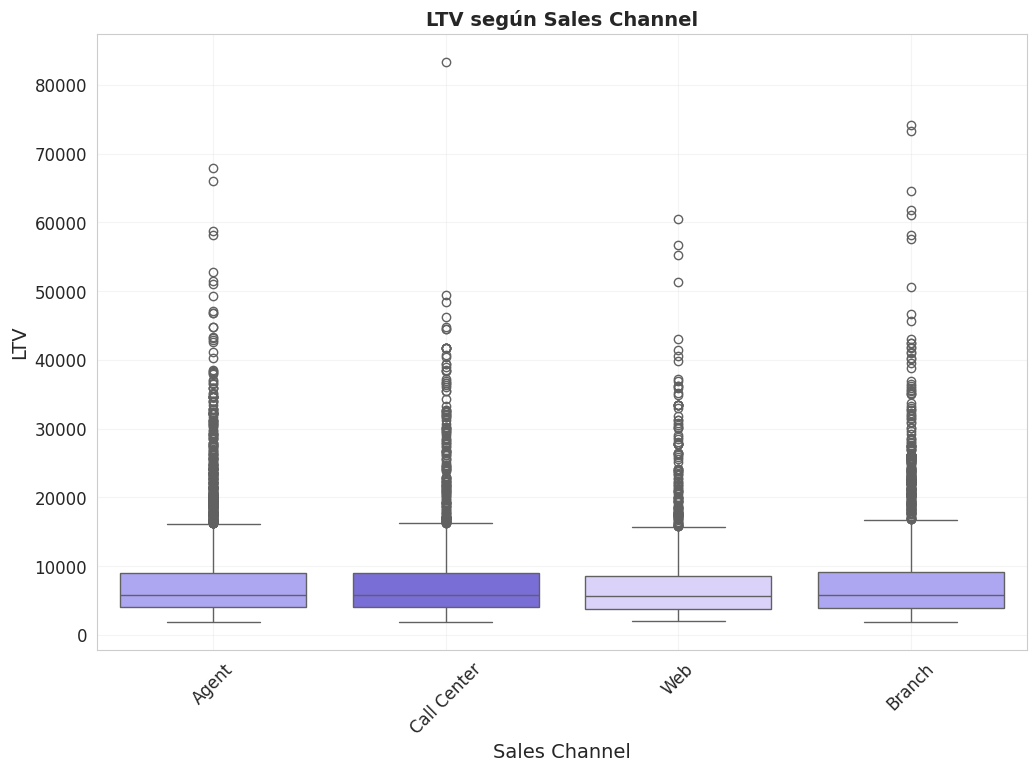

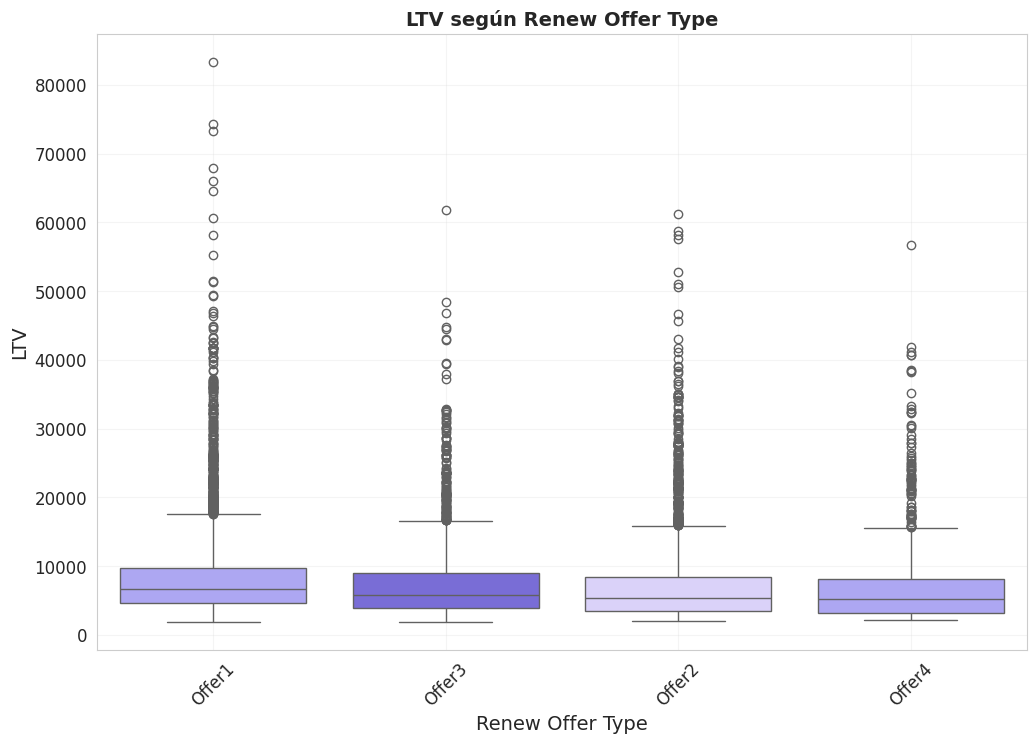

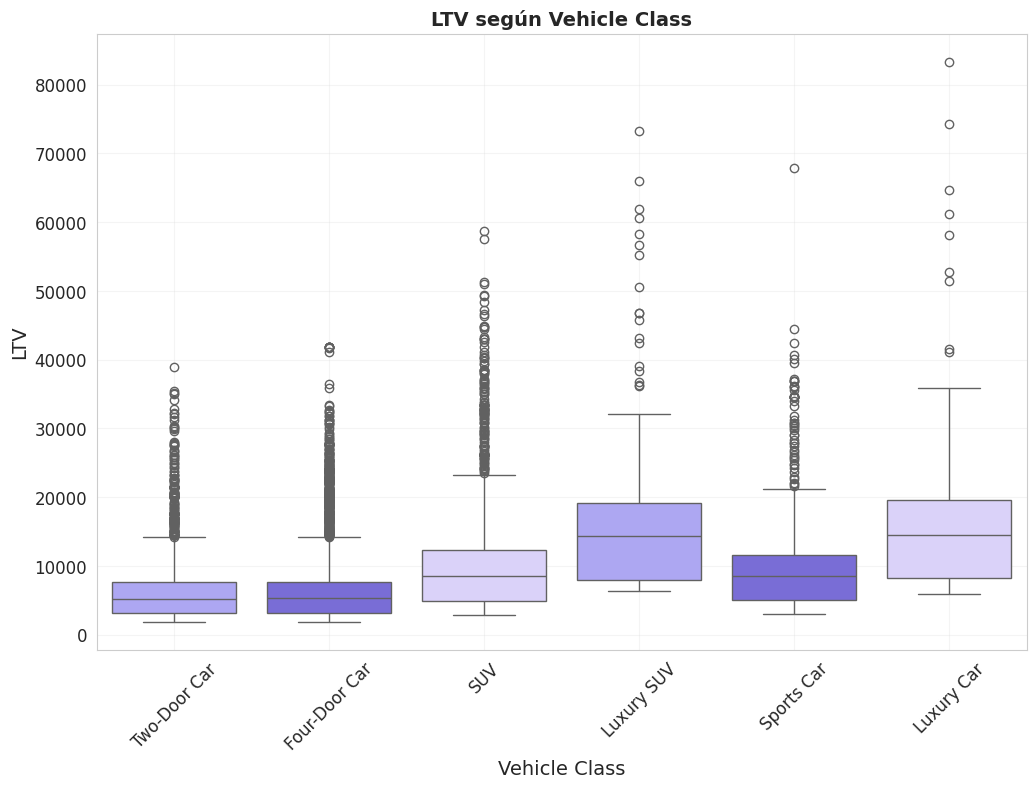

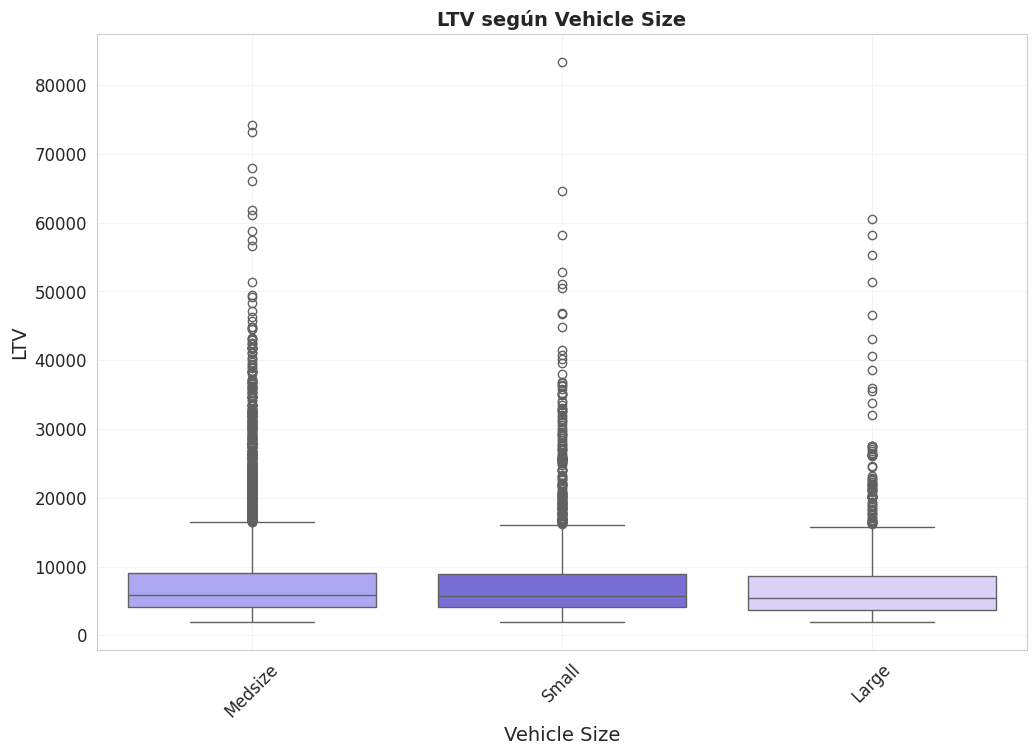

In [41]:
# ==============================
# LTV vs VARIABLES CATEGÓRICAS (SELECCIONADAS)
# ==============================

palette = ["#A29BFE", "#6C5CE7", "#D6CCFF"]

cat_cols_selected = [
    'Coverage',
    'EmploymentStatus',
    'Policy Type',
    'Policy',
    'Sales Channel',
    'Renew Offer Type',
    'Vehicle Class',
    'Vehicle Size'
]

for col in cat_cols_selected:
    plt.figure()

    sns.boxplot(
        data=df,
        x=col,
        y='Customer Lifetime Value',
        palette=palette
    )

    plt.title(f"LTV según {col}", fontsize=14, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel("LTV")

    plt.xticks(rotation=45)
    plt.grid(alpha=0.2)

    plt.show()

#LTV vs Coverage

Se observa que los clientes con cobertura premium presentan valores de LTV más elevados en comparación con aquellos con cobertura básica o extendida, lo que sugiere que un mayor nivel de cobertura está asociado a un mayor valor del cliente.

#LTV vs Employment Status

Los clientes empleados tienden a presentar valores de LTV más altos en comparación con otros estados laborales, lo que podría estar relacionado con una mayor capacidad de pago y estabilidad financiera.

#LTV vs Policy Type

Se identifican diferencias en el LTV según el tipo de póliza, destacándose ciertos segmentos que presentan valores superiores, lo que indica que algunos productos generan mayor valor para la empresa.

#LTV vs Sales Channel

El canal de ventas muestra variaciones en el LTV, sugiriendo que algunos canales, como agentes o brokers, podrían estar asociados a clientes de mayor valor.

#LTV vs Renew Offer Type

Se observan diferencias en el LTV según el tipo de oferta de renovación, lo que podría indicar que ciertas estrategias comerciales son más efectivas para retener clientes de alto valor.

#LTV vs Vehicle Class

Los clientes con vehículos de mayor categoría (como SUV o luxury) presentan valores más altos de LTV, lo que refleja una relación entre el tipo de vehículo y el valor económico del cliente.

#LTV vs Vehicle Size

Se observan leves diferencias en el LTV según el tamaño del vehículo, aunque sin una tendencia marcadamente definida.

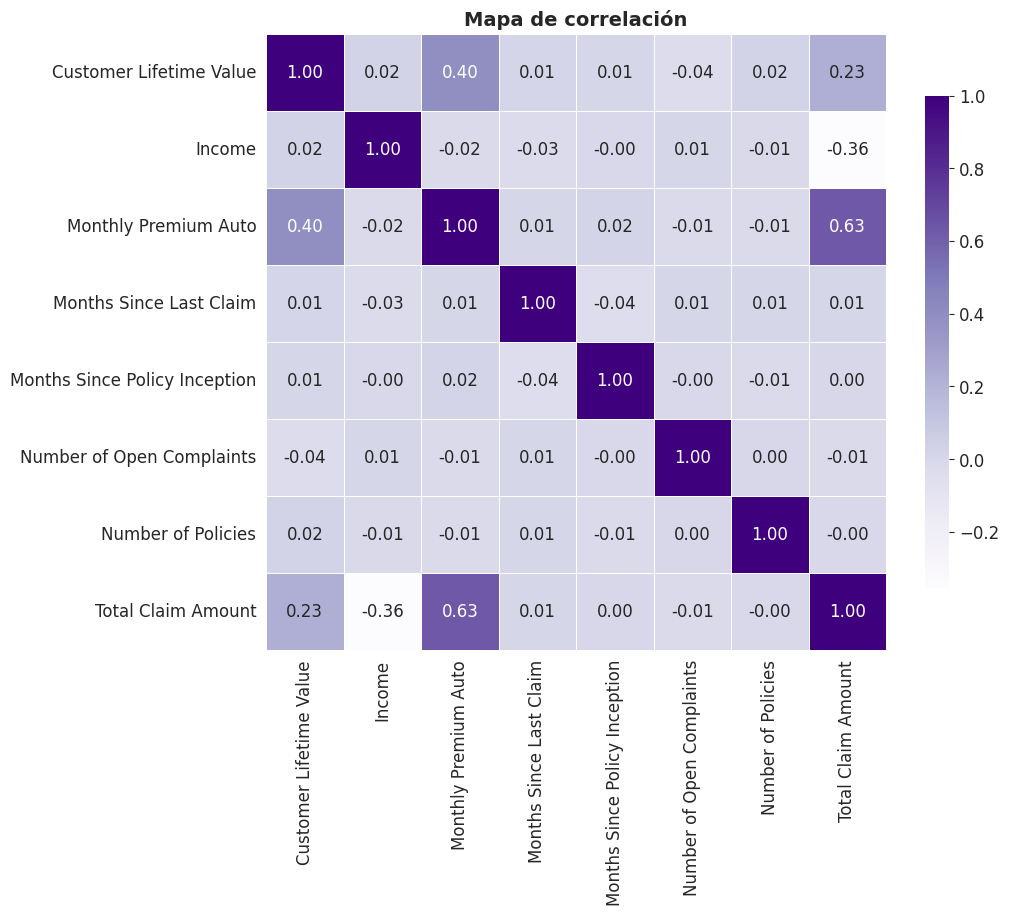

In [42]:
# ==============================
# CORRELACIONES
# ==============================

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Purples",
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8}
)

plt.title("Mapa de correlación", fontsize=14, fontweight='bold')

plt.show()

A partir del análisis del mapa de correlación, se observa que la variable Customer Lifetime Value (LTV) presenta una correlación positiva moderada con Monthly Premium Auto (0.40), lo que indica que los clientes con primas mensuales más altas tienden a generar mayor valor para la empresa.

Asimismo, se identifica una correlación positiva, aunque más débil, con Total Claim Amount (0.23), sugiriendo que clientes con mayor nivel de interacción (medido a través de reclamos) pueden presentar un mayor LTV.

Por otro lado, variables como Income, Months Since Last Claim y Months Since Policy Inception presentan correlaciones cercanas a cero con el LTV, lo que indica una baja relación lineal con la variable objetivo.

Adicionalmente, se observa una correlación relativamente alta entre Monthly Premium Auto y Total Claim Amount (0.63), lo que podría indicar cierta relación entre el monto de las primas y el nivel de reclamos.

En general, no se evidencian problemas de multicolinealidad severa entre las variables, lo que permite avanzar con el modelado sin necesidad de eliminar variables por redundancia.

***MODELADO Y EVALUACIÓN***

In [43]:
# ==============================
# FEATURE ENGINEERING
# ==============================

if 'Effective To Date' in df.columns:
    df['Effective To Date'] = pd.to_datetime(df['Effective To Date'])
    df['Effective_Year'] = df['Effective To Date'].dt.year
    df['Effective_Month'] = df['Effective To Date'].dt.month
    df = df.drop(columns=['Effective To Date'])

df['Customer_Tenure_Months'] = df['Months Since Policy Inception']
df['Annual_Premium_Estimated'] = df['Monthly Premium Auto'] * 12
df['Total_Premium_Estimated'] = df['Monthly Premium Auto'] * df['Customer_Tenure_Months']
df['Multi_Policy_Flag'] = (df['Number of Policies'] > 1).astype(int)

In [44]:
TARGET = "Customer Lifetime Value"

X = df.drop(columns=[TARGET, "Customer"])
y = df[TARGET]

num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
model_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

In [46]:
from sklearn.tree import DecisionTreeRegressor

model_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(max_depth=6, min_samples_leaf=50, random_state=42))
])

model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

In [47]:
from sklearn.ensemble import RandomForestRegressor

model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=30,
        random_state=42,
        n_jobs=-1
    ))
])

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

In [48]:
results = pd.DataFrame({
    "Modelo": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R2": [r2_lr, r2_dt, r2_rf],
    "MAE": [mae_lr, mae_dt, mae_rf],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf]
})

display(results)

,Modelo,R2,MAE,RMSE
0,Linear Regression,0.491182,2937.305248,5120.791080
1,Decision Tree,0.674467,1718.275239,4095.937971
2,Random Forest,0.680453,1649.006490,4058.108046


In [49]:
best_model = results.sort_values(by="RMSE").iloc[0]

print("Mejor modelo seleccionado:")
print(best_model)

Mejor modelo seleccionado:
Modelo    Random Forest
R2             0.680453
MAE          1649.00649
RMSE        4058.108046
Name: 2, dtype: object


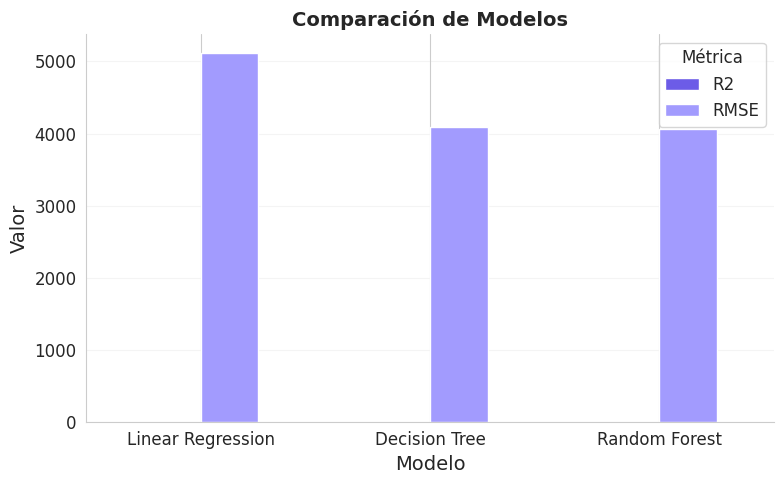

In [51]:
# ==============================
# Comparación de Modelos
# ==============================

ax = results.set_index("Modelo")[["R2", "RMSE"]].plot(
    kind="bar",
    figsize=(8,5),
    color=["#6C5CE7", "#A29BFE"]
)

plt.title("Comparación de Modelos", fontsize=14, fontweight="bold")
plt.ylabel("Valor")
plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(title="Métrica")

plt.tight_layout()
plt.show()

Se evaluaron tres modelos de regresión: Regresión Lineal, Árbol de Decisión y Random Forest, con el objetivo de predecir el Customer Lifetime Value (LTV).

Los resultados obtenidos muestran que la Regresión Lineal presenta el menor desempeño, con un R² de 0.49, lo que indica una capacidad limitada para capturar la variabilidad de los datos.

Por otro lado, el Árbol de Decisión mejora significativamente los resultados, alcanzando un R² de 0.67, lo que evidencia la presencia de relaciones no lineales entre las variables.

Finalmente, el modelo Random Forest presenta el mejor desempeño, con un R² de 0.68 y el menor error (RMSE), posicionándose como el modelo más adecuado para este problema.

Estos resultados confirman que modelos basados en árboles permiten capturar mejor la complejidad del comportamiento del cliente en comparación con modelos lineales